In [6]:
# !pip install meshio matplotlib
!pip install meshio
!pip install importlib
!pip install pandas
import importlib
import functions  # your module name
importlib.reload(functions)

<module 'functions' from '/Volumes/Songyi Deng/songyidengx/Downloads/ddgclib/functions.py'>

Geo file 'spheroid.geo' created.
Running gmsh to generate mesh 'spheroid_coarse.msh' ...
Info    : Running 'gmsh spheroid.geo -3 -format msh2 -o spheroid_coarse.msh' [Gmsh 4.13.1, 1 node, max. 1 thread]
Info    : Started on Wed Jun  4 22:44:38 2025
Info    : Reading 'spheroid.geo'...
Info    : Meshing 1D...
Info    : [ 40%] Meshing curve 2 (Circle)
Info    : Done meshing 1D (Wall 0.000761167s, CPU 4.5e-05s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Sphere, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00478796s, CPU 0.002662s)
Info    : Meshing 3D...
Info    : 3D Meshing 1 volume with 1 connected component
Info    : Tetrahedrizing 83 nodes...
Info    : Done tetrahedrizing 91 nodes (Wall 0.000514958s, CPU 0.000332s)
Info    : Reconstructing mesh...
Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering boundary
Info    : Done reconstructing mesh (Wall 0.00112408s, CPU 0.000763s)
Info    : Found volume 1
Info    : It. 0 - 0 nod

/Volumes/Songyi Deng/songyidengx/Downloads/ddgclib/venv/lib/python3.13/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Volumes/Songyi Deng/songyidengx/Downloads/ddgclib/venv/lib/python3.13/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


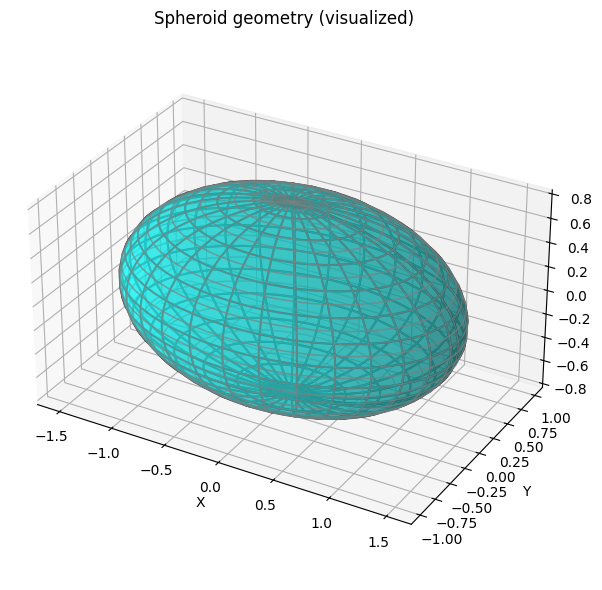

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

def generate_gmsh_sphere_geo(filename="sphere.geo", radius=1.0, lc=0.5):
    geo_str = f"""
SetFactory("OpenCASCADE");
Sphere(1) = {{0, 0, 0, {radius}}};
Mesh.CharacteristicLengthMin = {lc};
Mesh.CharacteristicLengthMax = {lc};
Mesh 3;
"""
    with open(filename, "w") as f:
        f.write(geo_str)
    print(f"Geo file '{filename}' created.")

def run_gmsh(geo_file="sphere.geo", msh_file="sphere.msh"):
    print(f"Running gmsh to generate mesh '{msh_file}' ...")
    os.system(f"gmsh {geo_file} -3 -format msh2 -o {msh_file}")

# ---- Parameters ----
radius_x = 1.5   # x-radius (ax)
radius_y = 1.0   # y-radius (ay)
radius_z = 0.8   # z-radius (az)
lc = 0.5         # mesh size

geo_filename = "spheroid.geo"
msh_filename = "spheroid_coarse.msh"

# ---- Generate geo and mesh ----
generate_gmsh_sphere_geo(filename=geo_filename, radius=1.0, lc=lc)  # geo is for unit sphere
run_gmsh(geo_file=geo_filename, msh_file=msh_filename)

# ---- Show geo file content ----
with open(geo_filename) as f:
    geo_content = f.read()

print("---- spheroid.geo ----\n")
print(geo_content)

# ---- Visualize spheroid geometry as image ----
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2 * np.pi, 60)
v = np.linspace(0, np.pi, 30)
x = radius_x * np.outer(np.cos(u), np.sin(v))
y = radius_y * np.outer(np.sin(u), np.sin(v))
z = radius_z * np.outer(np.ones_like(u), np.cos(v))

ax.plot_wireframe(x, y, z, color='black', alpha=0.7, rstride=2, cstride=2)
ax.plot_surface(x, y, z, color='cyan', alpha=0.5, edgecolor='gray')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Spheroid geometry (visualized)")
ax.set_box_aspect([radius_x, radius_y, radius_z])
plt.tight_layout()
plt.show()


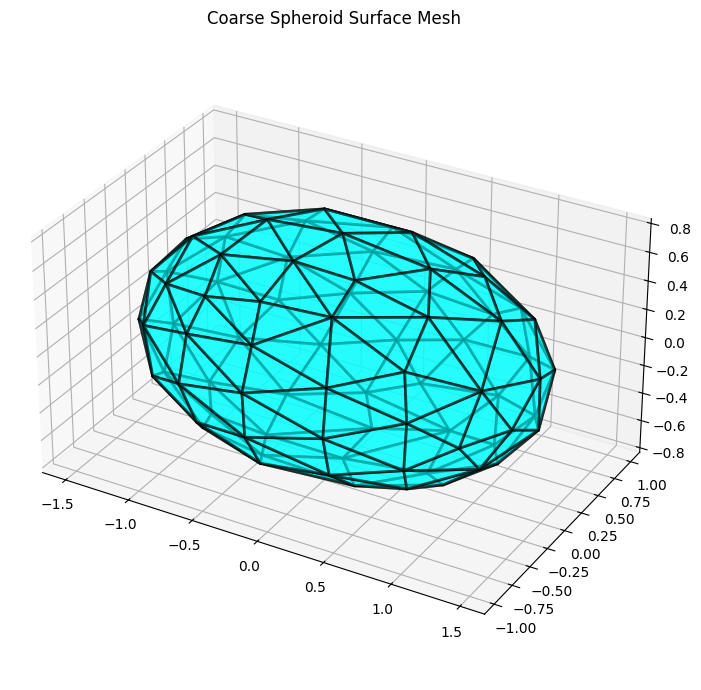

In [8]:
import meshio
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# --- Parameters for scaling (radii for spheroid) ---
radius_x = 1.5   # x-axis radius (ax)
radius_y = 1.0   # y-axis radius (ay)
radius_z = 0.8   # z-axis radius (az)
mesh_filename = "spheroid_coarse.msh"   # Use your mesh file here

# --- Load the mesh (should be a unit sphere mesh) ---
mesh = meshio.read(mesh_filename)
points = mesh.points

# --- Apply spheroid (ellipsoid) scaling ---
points_ellipsoid = points.copy()
points_ellipsoid[:,0] *= radius_x
points_ellipsoid[:,1] *= radius_y
points_ellipsoid[:,2] *= radius_z

tris = mesh.cells_dict["triangle"]

# --- Plot surface triangles only ---
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
mesh_tris = [[points_ellipsoid[i] for i in tri] for tri in tris]
poly = Poly3DCollection(mesh_tris, alpha=0.6)
poly.set_facecolor('cyan')
poly.set_linewidth(2)       # 2 points thick
poly.set_edgecolor('k')
ax.add_collection3d(poly)
#ax.scatter(points_ellipsoid[:,0], points_ellipsoid[:,1], points_ellipsoid[:,2], color='k', s=1)
ax.set_box_aspect([radius_x, radius_y, radius_z])
plt.title("Coarse Spheroid Surface Mesh")
plt.tight_layout()
plt.show()


Geo file 'sphere_lc0.10.geo' created.
Running gmsh to generate mesh 'sphere_lc0.10.msh' ...
Info    : Running 'gmsh sphere_lc0.10.geo -3 -format msh2 -o sphere_lc0.10.msh' [Gmsh 4.13.1, 1 node, max. 1 thread]
Info    : Started on Wed Jun  4 22:45:30 2025
Info    : Reading 'sphere_lc0.10.geo'...
Info    : Meshing 1D...
Info    : [ 40%] Meshing curve 2 (Circle)
Info    : Done meshing 1D (Wall 0.000380125s, CPU 5.3e-05s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Sphere, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0590548s, CPU 0.055206s)
Info    : Meshing 3D...
Info    : 3D Meshing 1 volume with 1 connected component
Info    : Tetrahedrizing 1578 nodes...
Info    : Done tetrahedrizing 1586 nodes (Wall 0.00784367s, CPU 0.007542s)
Info    : Reconstructing mesh...
Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering boundary
Info    : Done reconstructing mesh (Wall 0.0172408s, CPU 0.015996s)
Info    : Found volume 1
Info    : I

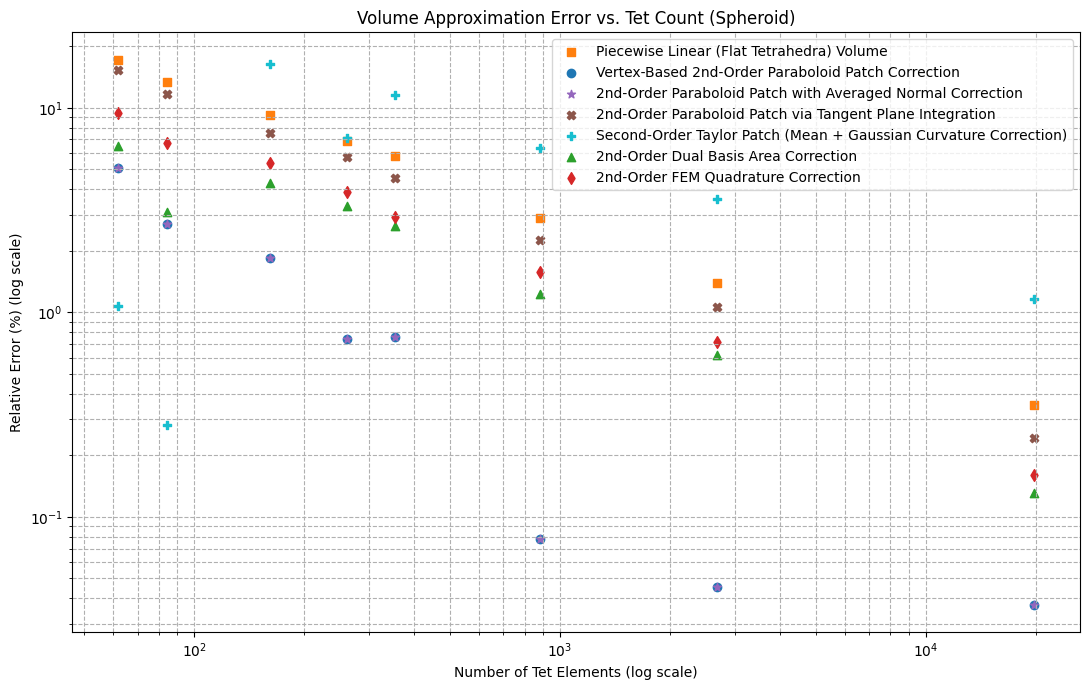

Saved to Spheroid_Plot.csv


In [10]:
from functions import run_volume_error_study_sphere, plot_volume_error_vs_tets
import importlib
import functions
import numpy as np
import pandas as pd

importlib.reload(functions)

# --- Spheroid radii ---
ax_ = 1.5   # x-axis radius
ay_ = 1.0   # y-axis radius
az_ = 0.8   # z-axis radius

# --- Mesh size values ---
lc_values = np.linspace(0.1, 0.8, 8)

# --- Run error study ---
results = run_volume_error_study_sphere(ax_, ay_, az_, lc_values)

# --- Plot results ---
plot_volume_error_vs_tets(*results, geometry_name="Spheroid")

# --- Save data to CSV ---
columns = [
    "Tet Count",
    "Piecewise Linear (Flat Tetrahedra) Volume",
    "Vertex-Based 2nd-Order Paraboloid Patch Correction",
    "2nd-Order Paraboloid Patch with Averaged Normal Correction",
    "2nd-Order Paraboloid Patch via Tangent Plane Integration",
    "Second-Order Taylor Patch (Mean + Gaussian Curvature Correction)",
    "2nd-Order Dual Basis Area Correction",
    "2nd-Order FEM Quadrature Correction"
]
data_dict = {col: res for col, res in zip(columns, results)}

df = pd.DataFrame(data_dict)
df.to_csv("Spheroid_Plot.csv", index=False)
print("Saved to Spheroid_Plot.csv")
